In [ ]:
!pip install gymnasium
!pip install "gymnasium[classic-control]"
!pip install swig
!pip install "gymnasium[box2d]"
!pip install numpy
!pip install stable-baselines3
!pip install shimmy
!pip install opencv-python

In [3]:
import stable_baselines3
import shimmy
import gymnasium as gym
from stable_baselines3 import PPO
import os
from stable_baselines3.common.monitor import Monitor
from gymnasium.wrappers import FrameStackObservation
from stable_baselines3.common.vec_env import DummyVecEnv, VecFrameStack
print(f"SB3 wersja: {stable_baselines3.__version__}")
log_dir = "./logs/"

SB3 wersja: 2.8.0


In [11]:
import gymnasium as gym
from stable_baselines3 import A2C
import cv2
def run_model(model,time=1000):
    vec_env = model.get_env()
    obs = vec_env.reset()
    window_name = "Agent view"

    for i in range(time):
        action, _state = model.predict(obs,deterministic=True)
        obs,reward,done,info = vec_env.step(action)
        frame = vec_env.render()
        frame_bgr = cv2.cvtColor(frame,cv2.COLOR_RGB2BGR)
        cv2.imshow(window_name,frame_bgr)
        key = cv2.waitKey(1) & 0xFF
        if cv2.getWindowProperty(window_name,cv2.WND_PROP_VISIBLE) < 1:
            break
        if key == ord('q'):
            break
        if done:
            obs = vec_env.reset()
    cv2.destroyAllWindows()
    vec_env.close()

### Samplowy problem z tyczką

In [ ]:
env = gym.make("CartPole-v1",render_mode="rgb_array")
model = A2C("MlpPolicy",env,verbose=1)
model.learn(total_timesteps=10000)

run_model(model)


Using cuda device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


/home/tk2/projekty/InteligencjaObliczeniowa/.venv/lib/python3.12/site-packages/stable_baselines3/common/on_policy_algorithm.py:150: UserWarning: You are trying to run A2C on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(


------------------------------------
| rollout/              |          |
|    ep_len_mean        | 21.3     |
|    ep_rew_mean        | 21.3     |
| time/                 |          |
|    fps                | 561      |
|    iterations         | 100      |
|    time_elapsed       | 0        |
|    total_timesteps    | 500      |
| train/                |          |
|    entropy_loss       | -0.69    |
|    explained_variance | 0.441    |
|    learning_rate      | 0.0007   |
|    n_updates          | 99       |
|    policy_loss        | 2.08     |
|    value_loss         | 9.82     |
------------------------------------
------------------------------------
| rollout/              |          |
|    ep_len_mean        | 24.8     |
|    ep_rew_mean        | 24.8     |
| time/                 |          |
|    fps                | 548      |
|    iterations         | 200      |
|    time_elapsed       | 1        |
|    total_timesteps    | 1000     |
| train/                |          |
|

### Na początku zacząłem z A2C na MlpPolicy co dało efekt przeuczenia - auto stoi

In [ ]:
env_car = gym.make("CarRacing-v3",render_mode="rgb_array")
model_car = A2C("MlpPolicy",env_car,verbose=1)
model_car.learn(total_timesteps=10000)
run_model(model_car)

### Potem skorzystałem z PPO i dostałem dużo lepsze wyniki

In [ ]:

env_car = gym.make("CarRacing-v3",render_mode="rgb_array")
model_car = PPO("CnnPolicy",env_car,verbose=1)
model_car.learn(total_timesteps=1000)
run_model(model_car)

Using cuda device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Wrapping the env in a VecTransposeImage.
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 1e+03    |
|    ep_rew_mean     | -57.1    |
| time/              |          |
|    fps             | 109      |
|    iterations      | 1        |
|    time_elapsed    | 18       |
|    total_timesteps | 2048     |
---------------------------------


### Czy GrayScale przyspiesza uczenie? - Nie

In [16]:
from gymnasium.wrappers import GrayscaleObservation
env_gray = gym.make("CarRacing-v3",render_mode="rgb_array")
env_gray = GrayscaleObservation(env_gray,keep_dim=True)
model_car = PPO("CnnPolicy",env_gray,verbose=1)
model_car.learn(total_timesteps=1000)
run_model(model_car)

Using cuda device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Wrapping the env in a VecTransposeImage.
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 1e+03    |
|    ep_rew_mean     | -59.6    |
| time/              |          |
|    fps             | 107      |
|    iterations      | 1        |
|    time_elapsed    | 19       |
|    total_timesteps | 2048     |
---------------------------------


### Logger do zapisu do plików

In [ ]:


os.makedirs(log_dir,exist_ok=True)
env_car = gym.make("CarRacing-v3",render_mode="rgb_array")
env_car = Monitor(env_car,log_dir)
model_car = PPO("CnnPolicy",env_car,verbose=1)
model_car.learn(total_timesteps=1000)

Using cuda device
Wrapping the env in a DummyVecEnv.
Wrapping the env in a VecTransposeImage.
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 1e+03    |
|    ep_rew_mean     | -59      |
| time/              |          |
|    fps             | 114      |
|    iterations      | 1        |
|    time_elapsed    | 17       |
|    total_timesteps | 2048     |
---------------------------------


### Eksperymenty z bardzo dużą ilością kroków

In [ ]:
env_car = gym.make("CarRacing-v3",render_mode="rgb_array")
env_car = Monitor(env_car,log_dir)
model_car = PPO("CnnPolicy",env_car,verbose=1)
model_car.learn(total_timesteps=200_000)
# run_model(model_car)

Using cuda device
Wrapping the env in a DummyVecEnv.
Wrapping the env in a VecTransposeImage.
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 1e+03    |
|    ep_rew_mean     | -58.5    |
| time/              |          |
|    fps             | 112      |
|    iterations      | 1        |
|    time_elapsed    | 18       |
|    total_timesteps | 2048     |
---------------------------------
------------------------------------------
| rollout/                |              |
|    ep_len_mean          | 1e+03        |
|    ep_rew_mean          | -53.5        |
| time/                   |              |
|    fps                  | 102          |
|    iterations           | 2            |
|    time_elapsed         | 39           |
|    total_timesteps      | 4096         |
| train/                  |              |
|    approx_kl            | 0.0044831485 |
|    clip_fraction        | 0.0676       |
|    clip_range           | 0.2          |
|    en

In [25]:
model_car.save("ppo_car_model_naive")

In [2]:
import matplotlib.pyplot as plt 
from stable_baselines3.common.results_plotter import plot_results
from stable_baselines3.common import results_plotter
plot_results([log_dir], 20_000, results_plotter.X_TIMESTEPS, "PPO CartPole")
plt.show()


NameError: name 'log_dir' is not defined

### Eksperymenty z framestackingiem

In [ ]:


env_car = gym.make("CarRacing-v3",render_mode="rgb_array")
env_car = Monitor(env_car,log_dir)
env_car = DummyVecEnv([lambda: env_car])
env_car = VecFrameStack(env_car, n_stack=4)
model_car = PPO("CnnPolicy",env_car,verbose=1)
model_car.learn(total_timesteps=1000)
# run_model(model_car)

In [4]:
def make_optimal_env():
    env = gym.make("CarRacing-v3",render_mode="rgb_array",continuous=False)
    env = DummyVecEnv([lambda: env])
    env = VecFrameStack(env, n_stack=4)
    return env

In [5]:
def run_model_opt(model,time=1000):
    vec_env = make_optimal_env()
    obs = vec_env.reset()
    window_name = "Agent view"

    for i in range(time):
        action, _state = model.predict(obs,deterministic=True)
        obs,reward,done,info = vec_env.step(action)
        frame = vec_env.render()
        frame_bgr = cv2.cvtColor(frame,cv2.COLOR_RGB2BGR)
        cv2.imshow(window_name,frame_bgr)
        key = cv2.waitKey(1) & 0xFF
        if cv2.getWindowProperty(window_name,cv2.WND_PROP_VISIBLE) < 1:
            break
        if key == ord('q'):
            break
        if done:
            obs = vec_env.reset()
    cv2.destroyAllWindows()
    vec_env.close()

### Dyskretyzacja akcji

In [35]:
from stable_baselines3.common.vec_env import DummyVecEnv,VecFrameStack
env_car = gym.make("CarRacing-v3",render_mode="rgb_array",continuous=False)
env_car = Monitor(env_car,log_dir)
env_car = DummyVecEnv([lambda: env_car])
env_car = VecFrameStack(env_car, n_stack=4)
model_car = PPO("CnnPolicy",env_car,verbose=1,learning_rate=0.0001)
model_car.learn(total_timesteps=50000)
model_car.save("ppo_car_model_discrete")
run_model(model_car)

Using cuda device
Wrapping the env in a VecTransposeImage.
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 1e+03    |
|    ep_rew_mean     | -56.4    |
| time/              |          |
|    fps             | 103      |
|    iterations      | 1        |
|    time_elapsed    | 19       |
|    total_timesteps | 2048     |
---------------------------------
-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 1e+03       |
|    ep_rew_mean          | -50.9       |
| time/                   |             |
|    fps                  | 91          |
|    iterations           | 2           |
|    time_elapsed         | 44          |
|    total_timesteps      | 4096        |
| train/                  |             |
|    approx_kl            | 0.013712382 |
|    clip_fraction        | 0.138       |
|    clip_range           | 0.2         |
|    entropy_loss         | -1.6        |
|    explaine

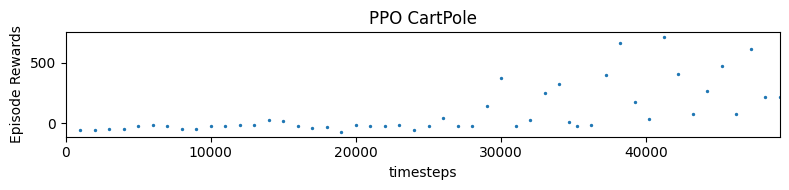

In [37]:
plot_results([log_dir], 50_000, results_plotter.X_TIMESTEPS, "PPO CartPole")
plt.show()

### Sprawdzanie na współczynniku dyskontowym 0.9

In [65]:
from stable_baselines3.common.vec_env import DummyVecEnv,VecFrameStack
env_car = gym.make("CarRacing-v3",render_mode="rgb_array",continuous=False)
env_car = Monitor(env_car,log_dir)
env_car = DummyVecEnv([lambda: env_car])
env_car = VecFrameStack(env_car, n_stack=4)
model_car = PPO("CnnPolicy",env_car,verbose=1,learning_rate=0.0001,gamma=0.9)
model_car.learn(total_timesteps=50000)
model_car.save("ppo_car_model_g09")
run_model_opt(model_car)

Using cuda device
Wrapping the env in a VecTransposeImage.
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 1e+03    |
|    ep_rew_mean     | -55.7    |
| time/              |          |
|    fps             | 108      |
|    iterations      | 1        |
|    time_elapsed    | 18       |
|    total_timesteps | 2048     |
---------------------------------
-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 1e+03       |
|    ep_rew_mean          | -44         |
| time/                   |             |
|    fps                  | 92          |
|    iterations           | 2           |
|    time_elapsed         | 44          |
|    total_timesteps      | 4096        |
| train/                  |             |
|    approx_kl            | 0.010032478 |
|    clip_fraction        | 0.108       |
|    clip_range           | 0.2         |
|    entropy_loss         | -1.6        |
|    explaine

### Dużo gorsze wyniki

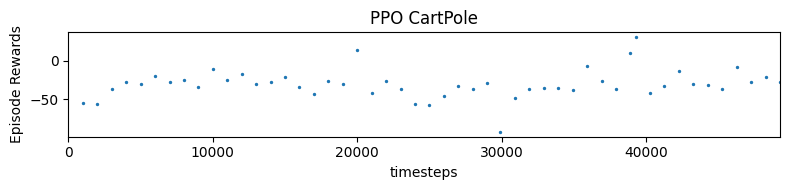

In [66]:
plot_results([log_dir], 50_000, results_plotter.X_TIMESTEPS, "PPO CartPole")
plt.show()

In [57]:
run_model_opt(model_car)

In [6]:
from typing import Callable
def linear_with_min(initial_value: float, min_value: float) -> Callable[[float], float]:
    def func(progress_remaining: float) -> float:
        return max(progress_remaining * initial_value, min_value)
    return func

In [68]:
from stable_baselines3.common.vec_env import DummyVecEnv,VecFrameStack
env_car = gym.make("CarRacing-v3",render_mode="rgb_array",continuous=True)
env_car = Monitor(env_car,log_dir)
env_car = DummyVecEnv([lambda: env_car])
env_car = VecFrameStack(env_car, n_stack=4)
lr_schedule = linear_with_min(0.001,0.00001)
model_car = PPO("CnnPolicy",env_car,verbose=1,learning_rate=0.0005,gamma=0.999)
model_car.learn(total_timesteps=500000)
model_car.save("ppo_car_model_cont")
run_model(model_car)

Using cuda device
Wrapping the env in a VecTransposeImage.
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 1e+03    |
|    ep_rew_mean     | -55.5    |
| time/              |          |
|    fps             | 112      |
|    iterations      | 1        |
|    time_elapsed    | 18       |
|    total_timesteps | 2048     |
---------------------------------
------------------------------------------
| rollout/                |              |
|    ep_len_mean          | 1e+03        |
|    ep_rew_mean          | -55.7        |
| time/                   |              |
|    fps                  | 101          |
|    iterations           | 2            |
|    time_elapsed         | 40           |
|    total_timesteps      | 4096         |
| train/                  |              |
|    approx_kl            | 0.0056143547 |
|    clip_fraction        | 0.0485       |
|    clip_range           | 0.2          |
|    entropy_loss         | -4.26        |

### Dla współczynnika dyskontowego = 0.999

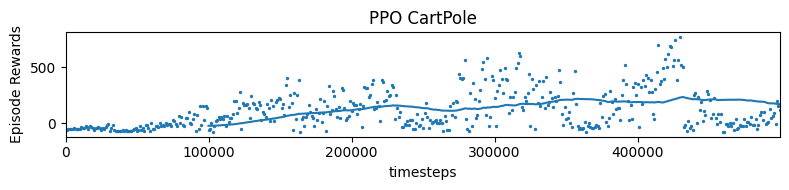

In [69]:
plot_results([log_dir], 500_000, results_plotter.X_TIMESTEPS, "PPO CartPole")
plt.show()

### Dodanie eval callbacku żeby wybrać najlepszy model + zmniejszającego się współczynnika uczenia bo wcześniej rezultaty były trochę zaszumione

In [5]:
from stable_baselines3.common.callbacks import EvalCallback, BaseCallback
class BestRewardLogger(BaseCallback):
    def __init__(self, verbose=0):
        super().__init__(verbose)

    def _on_step(self) -> bool:
        print(f"\n" + "="*30)
        print(f"NOWY REKORD: {self.parent.best_mean_reward:.2f} punktów!")
        print(f"Krok treningowy: {self.num_timesteps}")
        print("="*30 + "\n")
        return True

In [6]:
import shutil
import os

source = "./logs/best_model/best_model.zip"
log_source = "./logs/monitor.csv"
log_dir_cont_09 = "./logs/cont_09"
log_dir_cont_99 = "./logs/cont_99"
log_dir_cont_999 = "./logs/cont_999"
log_dir_cont_A2C = "./logs/cont_A2C"
log_dir_cont_DQN = "./logs/cont_DQN"
log_dir_disc_09 = "./logs/disc_09"

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

def moving_average(values, window):
    if len(values) < window:
        return values
    return pd.Series(values).rolling(window=window).mean()

def plot_comparison(log_dirs, labels, title="Porównanie Algorytmów"):
    plt.figure(figsize=(10, 6))
    
    for log_dir, label in zip(log_dirs, labels):
        file_path = os.path.join(log_dir, "monitor.csv")
        if not os.path.exists(file_path):
            print(f"Błąd: Nie znaleziono pliku w {file_path}")
            continue
            
        df = pd.read_csv(file_path, skiprows=1)
        x = np.cumsum(df['l'].values)
        y = df['r'].values
        y_smoothed = moving_average(y, window=50)
        plt.plot(x, y_smoothed, label=label)

    plt.xlabel('Liczba kroków (timesteps)')
    plt.ylabel('Średnia nagroda (wykładzona)')
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

# Zaczynamy testy

### Najpierw przypadek dyskretny

In [4]:
env_car = gym.make("CarRacing-v3",render_mode="rgb_array",continuous=False)
env_car = Monitor(env_car,log_dir_disc_09)
env_car = DummyVecEnv([lambda: env_car])
env_car = VecFrameStack(env_car, n_stack=4)

eval_env = gym.make("CarRacing-v3",render_mode="rgb_array",continuous=False)
eval_env = Monitor(eval_env)
eval_env = DummyVecEnv([lambda: eval_env])
eval_env = VecFrameStack(eval_env, n_stack=4)
eval_callback = EvalCallback(
    eval_env, 
    best_model_save_path="./logs/best_model/",
    log_path="./logs/results/", 
    eval_freq=10000,
    deterministic=True,
    n_eval_episodes=10,
    render=False,
    verbose=1,
    callback_on_new_best=BestRewardLogger()
)
model_car = PPO("CnnPolicy",env_car,verbose=1,gamma=0.9)
model_car.learn(total_timesteps=500_000,callback=eval_callback)

NameError: name 'log_dir_disc_09' is not defined

In [85]:
shutil.copy(source, "./modele_archiwum/model_05mln_g09_disc.zip")

'./modele_archiwum/model_05mln_g09_disc.zip'

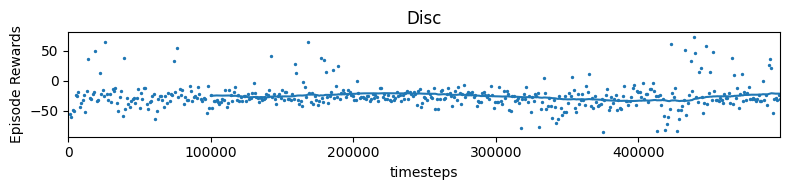

In [86]:
plot_results([log_dir_disc_09], 500_000, results_plotter.X_TIMESTEPS, "Disc")
plt.show()

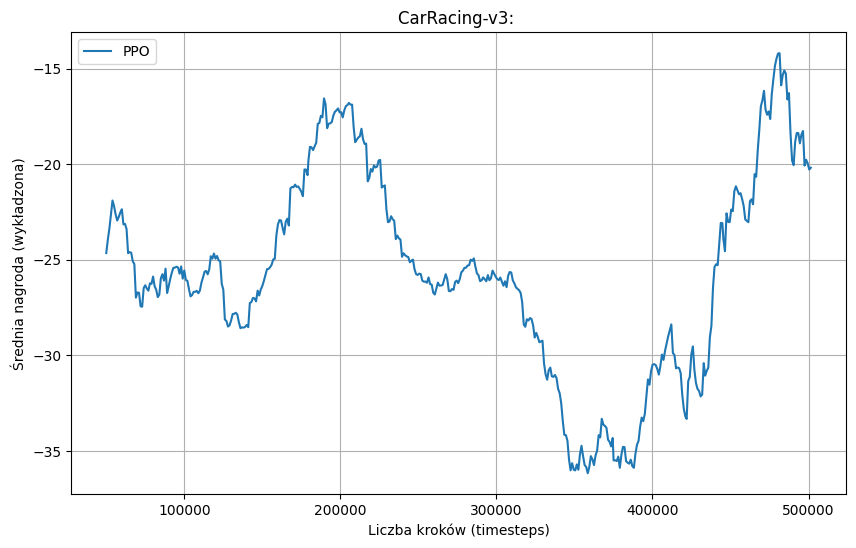

In [87]:
plot_comparison(
    log_dirs=["./logs/disc_09/"], 
    labels=["PPO"],
    title="CarRacing-v3: "
)

In [8]:
env_car = gym.make("CarRacing-v3",render_mode="rgb_array",continuous=True)
env_car = Monitor(env_car,log_dir_cont_09)
env_car = DummyVecEnv([lambda: env_car])
env_car = VecFrameStack(env_car, n_stack=4)

eval_env = gym.make("CarRacing-v3",render_mode="rgb_array",continuous=True)
eval_env = Monitor(eval_env)
eval_env = DummyVecEnv([lambda: eval_env])
eval_env = VecFrameStack(eval_env, n_stack=4)
eval_callback = EvalCallback(
    eval_env, 
    best_model_save_path="./logs/best_model/",
    log_path="./logs/results/", 
    eval_freq=10000,
    deterministic=True,
    n_eval_episodes=10,
    render=False,
    verbose=1,
    callback_on_new_best=BestRewardLogger()
)
model_car = PPO("CnnPolicy",env_car,verbose=1,gamma=0.9)
model_car.learn(total_timesteps=500_000,callback=eval_callback)

Using cuda device
Wrapping the env in a VecTransposeImage.


c:\Users\knotp\Documents\GitHub\InteligencjaObliczeniowa\.venv\Lib\site-packages\stable_baselines3\common\callbacks.py:419: UserWarning: Training and eval env are not of the same type<stable_baselines3.common.vec_env.vec_transpose.VecTransposeImage object at 0x0000023DA8E456A0> != <stable_baselines3.common.vec_env.vec_frame_stack.VecFrameStack object at 0x0000023DA8DFDA90>
  warnings.warn("Training and eval env are not of the same type" f"{self.training_env} != {self.eval_env}")


---------------------------------
| rollout/           |          |
|    ep_len_mean     | 1e+03    |
|    ep_rew_mean     | -56.2    |
| time/              |          |
|    fps             | 105      |
|    iterations      | 1        |
|    time_elapsed    | 19       |
|    total_timesteps | 2048     |
---------------------------------
-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 1e+03       |
|    ep_rew_mean          | -54.6       |
| time/                   |             |
|    fps                  | 95          |
|    iterations           | 2           |
|    time_elapsed         | 42          |
|    total_timesteps      | 4096        |
| train/                  |             |
|    approx_kl            | 0.009354584 |
|    clip_fraction        | 0.106       |
|    clip_range           | 0.2         |
|    entropy_loss         | -4.24       |
|    explained_variance   | 0.00224     |
|    learning_rate        | 0.

KeyboardInterrupt: 

In [ ]:
shutil.copy(source, "./modele_archiwum/model_05mln_g9_cont.zip")

'./modele_archiwum/model_05mln_g9_cont.zip'

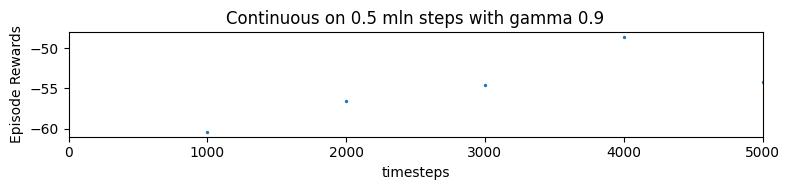

In [ ]:
plot_results([log_dir_cont_09], 500_000, results_plotter.X_TIMESTEPS, "Continuous on 0.5 mln steps with gamma 0.9")
plt.show()

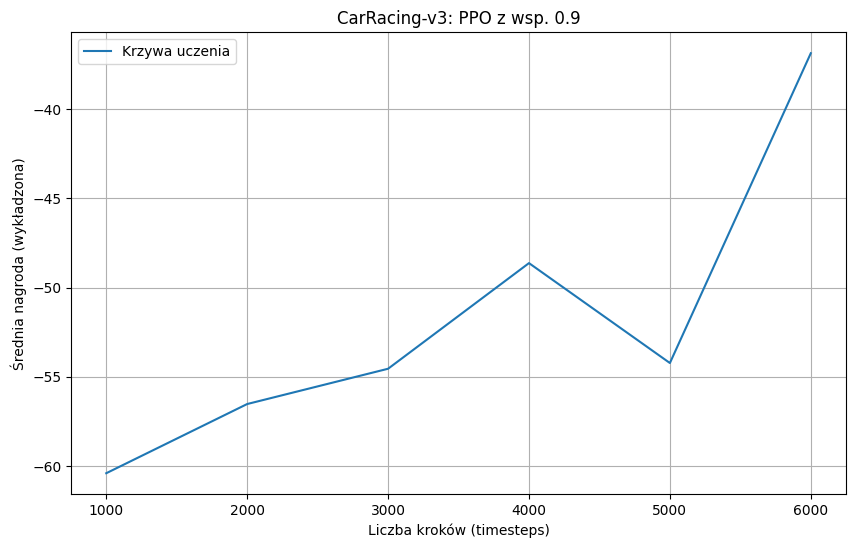

In [ ]:
plot_comparison(
    log_dirs=["./logs/cont_09/"], 
    labels=["Krzywa uczenia"],
    title="CarRacing-v3: PPO z wsp. 0.9"
)

### Następnie różne przypdki ciągłe z różnymi wartościami współczynnika dyskontowego

In [ ]:
env_car = gym.make("CarRacing-v3",render_mode="rgb_array",continuous=True)
env_car = Monitor(env_car,log_dir_cont_99)
env_car = DummyVecEnv([lambda: env_car])
env_car = VecFrameStack(env_car, n_stack=4)

eval_env = gym.make("CarRacing-v3",render_mode="rgb_array",continuous=True)
eval_env = Monitor(eval_env)
eval_env = DummyVecEnv([lambda: eval_env])
eval_env = VecFrameStack(eval_env, n_stack=4)
eval_callback = EvalCallback(
    eval_env, 
    best_model_save_path="./logs/best_model/",
    log_path="./logs/results/", 
    eval_freq=10000,
    deterministic=True,
    n_eval_episodes=10,
    render=False,
    verbose=1,
    callback_on_new_best=BestRewardLogger()
)
model_car = PPO("CnnPolicy",env_car,verbose=1)
model_car.learn(total_timesteps=500_000,callback=eval_callback)

Using cuda device
Wrapping the env in a VecTransposeImage.


c:\Users\knotp\Documents\GitHub\InteligencjaObliczeniowa\.venv\Lib\site-packages\stable_baselines3\common\callbacks.py:419: UserWarning: Training and eval env are not of the same type<stable_baselines3.common.vec_env.vec_transpose.VecTransposeImage object at 0x00000201047F3C20> != <stable_baselines3.common.vec_env.vec_frame_stack.VecFrameStack object at 0x00000201047F3EE0>
  warnings.warn("Training and eval env are not of the same type" f"{self.training_env} != {self.eval_env}")


---------------------------------
| rollout/           |          |
|    ep_len_mean     | 1e+03    |
|    ep_rew_mean     | -59.9    |
| time/              |          |
|    fps             | 92       |
|    iterations      | 1        |
|    time_elapsed    | 22       |
|    total_timesteps | 2048     |
---------------------------------
-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 1e+03       |
|    ep_rew_mean          | -55.7       |
| time/                   |             |
|    fps                  | 87          |
|    iterations           | 2           |
|    time_elapsed         | 46          |
|    total_timesteps      | 4096        |
| train/                  |             |
|    approx_kl            | 0.007839101 |
|    clip_fraction        | 0.0831      |
|    clip_range           | 0.2         |
|    entropy_loss         | -4.25       |
|    explained_variance   | 0.0183      |
|    learning_rate        | 0.

### Porównania (na podstawi zapisanych logów w plikach)

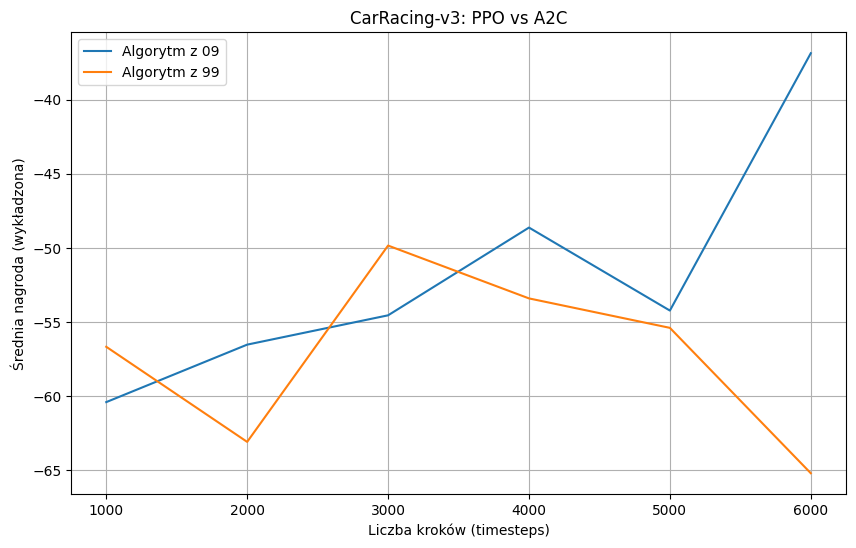

In [ ]:
plot_comparison(
    log_dirs=["./logs/cont_09/", "./logs/cont_99/"], 
    labels=["Algorytm z 09", "Algorytm z 99"],
    title="CarRacing-v3: PPO vs A2C"
)

In [ ]:
shutil.copy(source, "./modele_archiwum/model_05mln_g99_cont.zip")

'./modele_archiwum/model_05mln_g99_cont.zip'

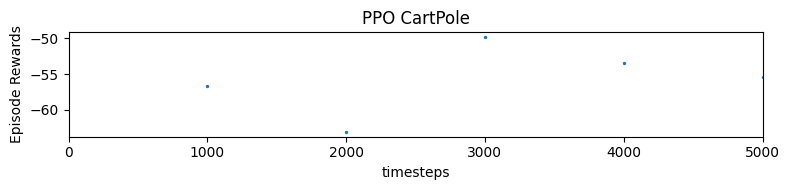

In [ ]:
plot_results([log_dir_cont_99], 500_000, results_plotter.X_TIMESTEPS, "PPO CartPole")
plt.show()

In [ ]:
env_car = gym.make("CarRacing-v3",render_mode="rgb_array",continuous=True)
env_car = Monitor(env_car,log_dir_cont_999)
env_car = DummyVecEnv([lambda: env_car])
env_car = VecFrameStack(env_car, n_stack=4)

eval_env = gym.make("CarRacing-v3",render_mode="rgb_array",continuous=True)
eval_env = Monitor(eval_env)
eval_env = DummyVecEnv([lambda: eval_env])
eval_env = VecFrameStack(eval_env, n_stack=4)
eval_callback = EvalCallback(
    eval_env, 
    best_model_save_path="./logs/best_model/",
    log_path="./logs/results/", 
    eval_freq=10000,
    deterministic=True,
    n_eval_episodes=10,
    render=False,
    verbose=1,
    callback_on_new_best=BestRewardLogger()
)
model_car = PPO("CnnPolicy",env_car,verbose=1,gamma=0.999)
model_car.learn(total_timesteps=500_000,callback=eval_callback)

Using cuda device
Wrapping the env in a VecTransposeImage.


c:\Users\knotp\Documents\GitHub\InteligencjaObliczeniowa\.venv\Lib\site-packages\stable_baselines3\common\callbacks.py:419: UserWarning: Training and eval env are not of the same type<stable_baselines3.common.vec_env.vec_transpose.VecTransposeImage object at 0x00000201047F0050> != <stable_baselines3.common.vec_env.vec_frame_stack.VecFrameStack object at 0x00000201047F3120>
  warnings.warn("Training and eval env are not of the same type" f"{self.training_env} != {self.eval_env}")


---------------------------------
| rollout/           |          |
|    ep_len_mean     | 1e+03    |
|    ep_rew_mean     | -58.8    |
| time/              |          |
|    fps             | 87       |
|    iterations      | 1        |
|    time_elapsed    | 23       |
|    total_timesteps | 2048     |
---------------------------------
------------------------------------------
| rollout/                |              |
|    ep_len_mean          | 1e+03        |
|    ep_rew_mean          | -52          |
| time/                   |              |
|    fps                  | 84           |
|    iterations           | 2            |
|    time_elapsed         | 48           |
|    total_timesteps      | 4096         |
| train/                  |              |
|    approx_kl            | 0.0044386457 |
|    clip_fraction        | 0.0527       |
|    clip_range           | 0.2          |
|    entropy_loss         | -4.26        |
|    explained_variance   | 0.0139       |
|    learning_r

In [ ]:
shutil.copy(source, "./modele_archiwum/model_05mln_g999_cont.zip")

'./modele_archiwum/model_05mln_g999_cont.zip'

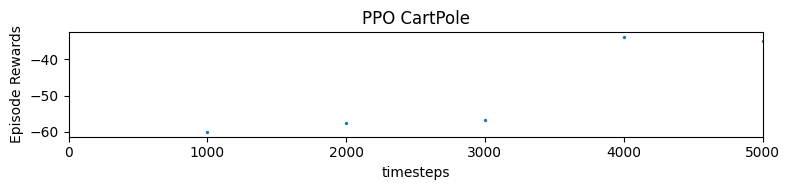

In [ ]:
plot_results([log_dir_cont_999], 500_000, results_plotter.X_TIMESTEPS, "PPO CartPole")
plt.show()

In [13]:
!pip install tensorboard

   ---------------------------------------- 0.0/5.5 MB ? eta -:--:--
   ------- -------------------------------- 1.0/5.5 MB 8.9 MB/s eta 0:00:01
   ------------------------ --------------- 3.4/5.5 MB 10.7 MB/s eta 0:00:01
   ---------------------------------------- 5.5/5.5 MB 10.8 MB/s  0:00:00
   ---------------------------------------- 0.0/4.9 MB ? eta -:--:--
   --------------- ------------------------ 1.8/4.9 MB 9.2 MB/s eta 0:00:01
   ------------------------------ --------- 3.7/4.9 MB 9.3 MB/s eta 0:00:01
   ---------------------------------------- 4.9/4.9 MB 9.1 MB/s  0:00:00

   ---------------------------------------- 0/7 [werkzeug]
   ----------- ---------------------------- 2/7 [protobuf]
   ----------------- ---------------------- 3/7 [markdown]
   ---------------------- ----------------- 4/7 [grpcio]
   ---------------------------- ----------- 5/7 [absl-py]
   ---------------------------------- ----- 6/7 [tensorboard]
   ---------------------------------- ----- 6/7 [tensor


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


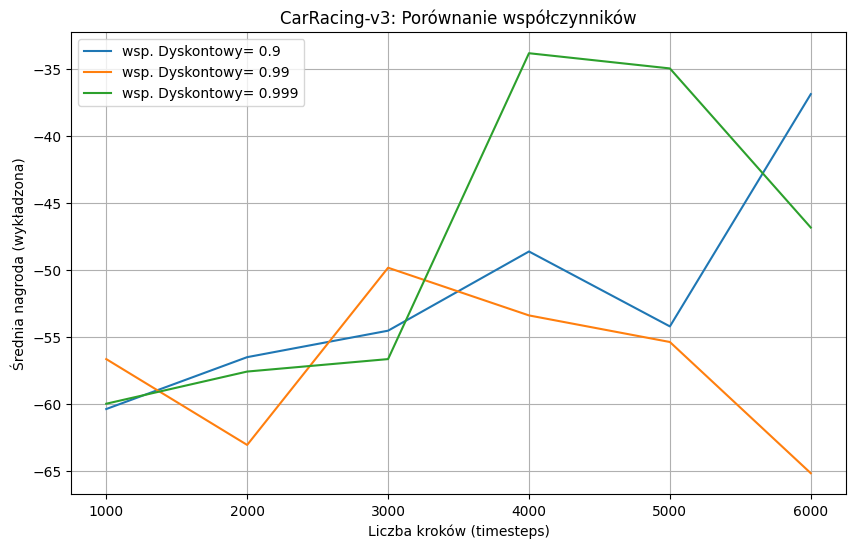

In [ ]:
plot_comparison(
    log_dirs=["./logs/cont_09/", "./logs/cont_99/", "./logs/cont_999/"], 
    labels=["wsp. Dyskontowy= 0.9", "wsp. Dyskontowy= 0.99", "wsp. Dyskontowy= 0.999"],
    title="CarRacing-v3: Porównanie współczynników"
)

# Dwa algorytmy do implementacji???

### Actor-Critic

In [ ]:
env_car = gym.make("CarRacing-v3",render_mode="rgb_array",continuous=True)
env_car = Monitor(env_car,log_dir_cont_A2C)
env_car = DummyVecEnv([lambda: env_car])
env_car = VecFrameStack(env_car, n_stack=4)

eval_env = gym.make("CarRacing-v3",render_mode="rgb_array",continuous=True)
eval_env = Monitor(eval_env)
eval_env = DummyVecEnv([lambda: eval_env])
eval_env = VecFrameStack(eval_env, n_stack=4)
eval_callback = EvalCallback(
    eval_env, 
    best_model_save_path="./logs/best_model/",
    log_path="./logs/results/", 
    eval_freq=10000,
    deterministic=True,
    n_eval_episodes=10,
    render=False,
    verbose=1,
    callback_on_new_best=BestRewardLogger()
)
model_car = A2C("CnnPolicy",env_car,verbose=1)
model_car.learn(total_timesteps=500_000,callback=eval_callback)

Using cuda device
Wrapping the env in a VecTransposeImage.


c:\Users\knotp\Documents\GitHub\InteligencjaObliczeniowa\.venv\Lib\site-packages\stable_baselines3\common\callbacks.py:419: UserWarning: Training and eval env are not of the same type<stable_baselines3.common.vec_env.vec_transpose.VecTransposeImage object at 0x00000201047F1020> != <stable_baselines3.common.vec_env.vec_frame_stack.VecFrameStack object at 0x00000201047F38B0>
  warnings.warn("Training and eval env are not of the same type" f"{self.training_env} != {self.eval_env}")


------------------------------------
| time/                 |          |
|    fps                | 77       |
|    iterations         | 100      |
|    time_elapsed       | 6        |
|    total_timesteps    | 500      |
| train/                |          |
|    entropy_loss       | -4.23    |
|    explained_variance | -0.0395  |
|    learning_rate      | 0.0007   |
|    n_updates          | 99       |
|    policy_loss        | -0.291   |
|    std                | 0.991    |
|    value_loss         | 0.00468  |
------------------------------------
------------------------------------
| rollout/              |          |
|    ep_len_mean        | 1e+03    |
|    ep_rew_mean        | -64.9    |
| time/                 |          |
|    fps                | 76       |
|    iterations         | 200      |
|    time_elapsed       | 13       |
|    total_timesteps    | 1000     |
| train/                |          |
|    entropy_loss       | -4.22    |
|    explained_variance | 0.523    |
|

In [ ]:
shutil.copy(source, "./modele_archiwum/model_05mln_g99_cont_a2c.zip")

'./modele_archiwum/model_05mln_g99_cont_a2c.zip'

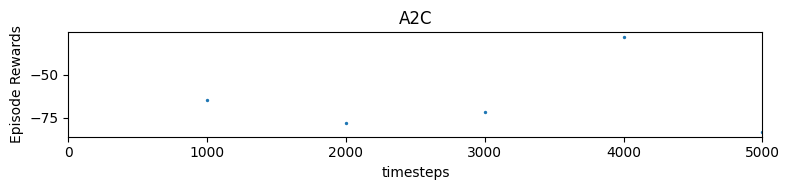

In [ ]:
plot_results([log_dir_cont_A2C], 500_000, results_plotter.X_TIMESTEPS, "A2C")
plt.show()

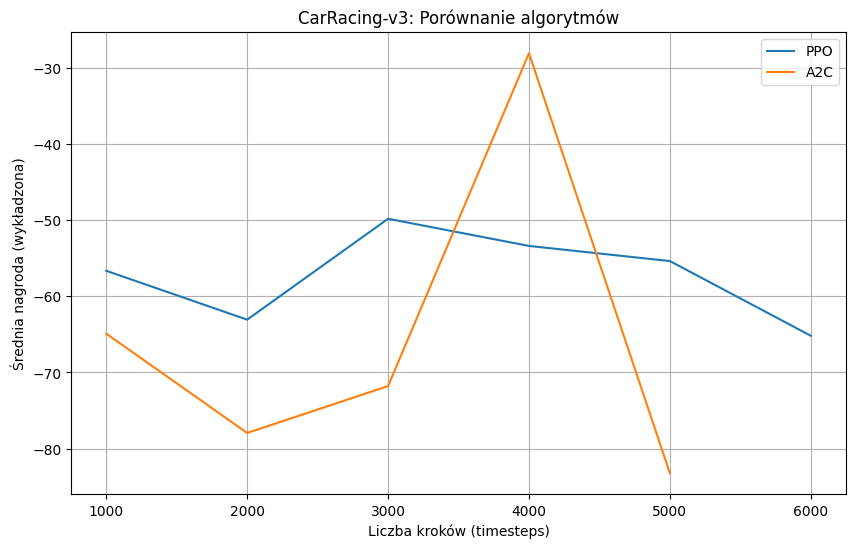

In [ ]:
plot_comparison(
    log_dirs=["./logs/cont_99/", "./logs/cont_A2C/"], 
    labels=["PPO", "A2C"],
    title="CarRacing-v3: Porównanie algorytmów"
)

### Wczytywanie modelu z zipa

In [12]:
env_car = gym.make("CarRacing-v3",render_mode="rgb_array",continuous=False)
env_car = Monitor(env_car,log_dir)
env_car = DummyVecEnv([lambda: env_car])
env_car = VecFrameStack(env_car, n_stack=4)
model = PPO.load("./modele_archiwum/model_05mln_g09_disc", env=env_car)
run_model(model)

Wrapping the env in a VecTransposeImage.
